# 📊 Employee Attrition Prediction using Machine Learning
**Week 2 — Internship Project**  
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
**Objective:** Build a Machine Learning system that predicts whether an employee is likely to leave the company based on HR factors.

---

In [17]:
# ============================================================
# IMPORTS & SETUP
# All required libraries for the entire project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Create charts output folder
os.makedirs('charts', exist_ok=True)

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## Task 1 — Data Loading & Exploration
Load the dataset, understand its structure, and identify key characteristics of the target variable.

In [18]:
# ============================================================
# TASK 1 — DATA LOADING & EXPLORATION
# ============================================================

# Load dataset
df = pd.read_csv('HR_Attrition.csv')

# ── 1.1 First 10 rows ──
print('── First 10 Rows ──')
display(df.head(10))

── First 10 Rows ──


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [19]:
# ── 1.2 Dataset dimensions ──
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print()
print('── Column Data Types ──')
print(df.dtypes)

Rows    : 1470
Columns : 35

── Column Data Types ──
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
St

In [20]:
# ── 1.3 Target column: Attrition distribution ──
attrition_counts = df['Attrition'].value_counts()
attrition_rate   = (attrition_counts['Yes'] / len(df)) * 100

print('── Attrition Distribution ──')
print(attrition_counts)
print(f'\nAttrition Rate : {attrition_rate:.2f}%')
print(f'Retention Rate : {100 - attrition_rate:.2f}%')

── Attrition Distribution ──
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate : 16.12%
Retention Rate : 83.88%


In [21]:
# ── 1.4 Numeric vs Categorical columns ──
numeric_cols     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns    ({len(numeric_cols)}) : {numeric_cols}')
print(f'\nCategorical columns ({len(categorical_cols)}) : {categorical_cols}')

Numeric columns    (26) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [22]:
# ── 1.5 Observation ──
print("""
📝 OBSERVATION — Attrition Rate Balance
─────────────────────────────────────────────────────────────
The dataset is IMBALANCED.

Only ~16% of employees left (Attrition = Yes) while ~84% stayed.
This means a naive model that always predicts 'No Attrition' would
achieve ~84% accuracy — yet be completely useless for HR teams who
need to identify who IS leaving.

To handle this, we will use class_weight='balanced' during model
training so the algorithm penalises missed attrition predictions
more heavily than missed retention predictions.
─────────────────────────────────────────────────────────────
""")


📝 OBSERVATION — Attrition Rate Balance
─────────────────────────────────────────────────────────────
The dataset is IMBALANCED.

Only ~16% of employees left (Attrition = Yes) while ~84% stayed.
This means a naive model that always predicts 'No Attrition' would
achieve ~84% accuracy — yet be completely useless for HR teams who
need to identify who IS leaving.

To handle this, we will use class_weight='balanced' during model
training so the algorithm penalises missed attrition predictions
more heavily than missed retention predictions.
─────────────────────────────────────────────────────────────



---
## Task 2 — Data Cleaning & Preprocessing
Remove irrelevant columns, encode categorical variables, and scale numerical features.

In [23]:
# ============================================================
# TASK 2 — DATA CLEANING & PREPROCESSING
# ============================================================

# Keep a clean copy for EDA in Task 3 (before encoding)
df_eda = df.copy()

# ── 2.1 Check for missing values ──
missing = df.isnull().sum()
print('── Missing Values ──')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found. ✅')

── Missing Values ──
No missing values found. ✅


In [24]:
# ── 2.2 Drop columns that add no predictive value ──
# EmployeeNumber : unique identifier (not a feature)
# Over18         : all employees are over 18 — zero variance
# StandardHours  : all values are 80 — zero variance
# EmployeeCount  : all values are 1 — zero variance

cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped columns : {cols_to_drop}')
print(f'Remaining shape : {df.shape}')

Dropped columns : ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Remaining shape : (1470, 31)


In [25]:
# ── 2.3 Encode target column: Yes → 1, No → 0 ──
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print('Target encoding: Yes=1, No=0')
print(df['Attrition'].value_counts())

Target encoding: Yes=1, No=0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [26]:
# ── 2.4 One-Hot Encode categorical features ──
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}\n')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Shape after one-hot encoding: {df.shape}')

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after one-hot encoding: (1470, 45)


In [27]:
# ── 2.5 Separate features and target, then scale ──
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Preprocessing complete.')
print(f'Features : {X_scaled.shape[1]}')
print(f'Samples  : {X_scaled.shape[0]}')

✅ Preprocessing complete.
Features : 44
Samples  : 1470


---
## Task 3 — Exploratory Data Analysis (EDA)
Uncover patterns in the data that explain why employees leave.

In [28]:
# ============================================================
# TASK 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Add numeric attrition column to the EDA copy
df_eda['Attrition_Num'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

# ── 3.1 Attrition Rate by Department ──
dept_attrition = (
    df_eda.groupby('Department')['Attrition_Num']
    .mean().mul(100).round(2)
    .sort_values(ascending=False)
)
print('── Attrition Rate by Department (%) ──')
print(dept_attrition)
print(f'\nHighest: {dept_attrition.idxmax()} ({dept_attrition.max()}%)')

── Attrition Rate by Department (%) ──
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Num, dtype: float64

Highest: Sales (20.63%)


In [29]:
# ── 3.2 Attrition Rate by Job Role ──
role_attrition = (
    df_eda.groupby('JobRole')['Attrition_Num']
    .mean().mul(100).round(2)
    .sort_values(ascending=False)
)
print('── Attrition Rate by Job Role (%) ──')
print(role_attrition)

── Attrition Rate by Job Role (%) ──
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Num, dtype: float64


In [30]:
# ── 3.3 Attrition vs Monthly Income ──
income_by_attrition = df_eda.groupby('Attrition')['MonthlyIncome'].mean().round(0)
print('── Average Monthly Income by Attrition ──')
print(income_by_attrition)
diff_pct = ((income_by_attrition['No'] - income_by_attrition['Yes'])
            / income_by_attrition['No'] * 100)
print(f'\nEmployees who left earned {diff_pct:.1f}% less on average.')

── Average Monthly Income by Attrition ──
Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64

Employees who left earned 29.9% less on average.


In [31]:
# ── 3.4 Attrition vs Work-Life Balance ──
wlb_attrition = (
    df_eda.groupby('WorkLifeBalance')['Attrition_Num']
    .mean().mul(100).round(2)
)
print('── Attrition Rate by Work-Life Balance Rating ──')
print('(1 = Bad, 2 = Good, 3 = Better, 4 = Best)')
print(wlb_attrition)

── Attrition Rate by Work-Life Balance Rating ──
(1 = Bad, 2 = Good, 3 = Better, 4 = Best)
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition_Num, dtype: float64


In [32]:
# ── 3.5 Attrition vs Years at Company ──
tenure_by_attrition = df_eda.groupby('Attrition')['YearsAtCompany'].mean().round(2)
print('── Average Years at Company by Attrition ──')
print(tenure_by_attrition)

── Average Years at Company by Attrition ──
Attrition
No     7.37
Yes    5.13
Name: YearsAtCompany, dtype: float64


In [33]:
# ── 3.6 Business Insights ──
print("""
📝 BUSINESS INSIGHTS FROM EDA
─────────────────────────────────────────────────────────────────────

1. DEPARTMENT: The Sales department has the highest attrition rate
   (~20%), significantly above the company average of ~16%.
   Human Resources department also shows elevated exit rates.

2. JOB ROLE: Sales Representatives have the highest exit rate (~40%),
   nearly 2.5x the company average — a major HR red flag.
   Laboratory Technicians and Human Resources roles also rank high.

3. INCOME: Employees who left earned an average monthly income ~20%
   lower than those who stayed, confirming compensation as a factor.
   However, it is not the sole driver (see insight 4 and 5).

4. WORK-LIFE BALANCE: Employees with a Work-Life Balance rating of 1
   (worst) show the highest attrition rate. Even a rating of 2 shows
   notably elevated risk, suggesting burnout is a major factor.

5. TENURE: Employees who left had an average tenure of ~5 years, vs
   ~7 years for those who stayed. The first 5 years is the critical
   retention window — most exits happen before employees become senior.

─────────────────────────────────────────────────────────────────────
""")


📝 BUSINESS INSIGHTS FROM EDA
─────────────────────────────────────────────────────────────────────

1. DEPARTMENT: The Sales department has the highest attrition rate
   (~20%), significantly above the company average of ~16%.
   Human Resources department also shows elevated exit rates.

2. JOB ROLE: Sales Representatives have the highest exit rate (~40%),
   nearly 2.5x the company average — a major HR red flag.
   Laboratory Technicians and Human Resources roles also rank high.

3. INCOME: Employees who left earned an average monthly income ~20%
   lower than those who stayed, confirming compensation as a factor.
   However, it is not the sole driver (see insight 4 and 5).

4. WORK-LIFE BALANCE: Employees with a Work-Life Balance rating of 1
   (worst) show the highest attrition rate. Even a rating of 2 shows
   notably elevated risk, suggesting burnout is a major factor.

5. TENURE: Employees who left had an average tenure of ~5 years, vs
   ~7 years for those who stayed. The firs

---
## Task 4 — Model Building & Comparison
Train three classification models and compare their performance.

In [34]:
# ============================================================
# TASK 4 — MODEL BUILDING & COMPARISON
# ============================================================

# ── 4.1 Train-Test Split (80/20) with stratification ──
# stratify=y ensures the same attrition ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'\nAttrition ratio in training set : {y_train.mean()*100:.2f}%')
print(f'Attrition ratio in test set     : {y_test.mean()*100:.2f}%')

Training samples : 1176
Test samples     : 294

Attrition ratio in training set : 16.16%
Attrition ratio in test set     : 15.99%


In [35]:
# ── 4.2 Define models ──
# class_weight='balanced' handles class imbalance by internally
# weighting minority class (Attrition=Yes) more heavily during training.

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

# ── 4.3 Train all models ──
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅ {name} — trained.')

✅ Logistic Regression — trained.
✅ Random Forest — trained.
✅ Gradient Boosting — trained.


---
## Task 5 — Model Evaluation
Evaluate all three models using multiple metrics and identify the best performer.

In [36]:
# ============================================================
# TASK 5 — MODEL EVALUATION
# ============================================================

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report  = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model'                   : name,
        'Precision (Attrition)'   : round(report['1']['precision'], 3),
        'Recall (Attrition)'      : round(report['1']['recall'],    3),
        'F1-Score (Attrition)'    : round(report['1']['f1-score'],  3),
        'ROC-AUC'                 : round(roc_auc, 3)
    })

    print(f'\n{'─'*50}')
    print(f'  {name}')
    print(f'{'─'*50}')
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print(f'  ROC-AUC Score : {roc_auc:.4f}')


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

  ROC-AUC Score : 0.7986

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294

  ROC-AUC Score : 0.7519

──────────────────────────────────────────────────


In [37]:
# ── 5.1 Model Comparison Table ──
results_df = pd.DataFrame(results).set_index('Model')
print('\n── Model Comparison Table ──')
display(results_df.style.highlight_max(color='lightgreen').format(precision=3))


── Model Comparison Table ──


,Precision (Attrition),Recall (Attrition),F1-Score (Attrition),ROC-AUC
Model,,,,
Logistic Regression,0.341,0.617,0.439,0.799
Random Forest,0.375,0.064,0.109,0.752
Gradient Boosting,0.588,0.213,0.312,0.794


In [38]:
# ── 5.2 Identify Best Model ──
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = trained_models[best_model_name]

print(f'🏆 Best Model : {best_model_name}')
print(f'   ROC-AUC   : {results_df.loc[best_model_name, "ROC-AUC"]}')
print()
print('Reason: ROC-AUC is the most informative metric for an imbalanced')
print('classification task. It measures the model\'s ability to distinguish')
print('employees who will leave from those who will stay, across all decision')
print('thresholds — not just at the default 0.5 cutoff.')

🏆 Best Model : Logistic Regression
   ROC-AUC   : 0.799

Reason: ROC-AUC is the most informative metric for an imbalanced
classification task. It measures the model's ability to distinguish
employees who will leave from those who will stay, across all decision
thresholds — not just at the default 0.5 cutoff.


In [39]:
# ── 5.3 Feature Importance — Top 10 Drivers of Attrition ──
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    # Logistic Regression: use absolute coefficient values
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)

top10_features = importances.sort_values(ascending=False).head(10)

print(f'── Top 10 Features Driving Attrition ({best_model_name}) ──')
for i, (feat, score) in enumerate(top10_features.items(), 1):
    print(f'  {i:>2}. {feat:<45} {score:.4f}')

── Top 10 Features Driving Attrition (Logistic Regression) ──
   1. JobRole_Laboratory Technician                 0.7979
   2. OverTime_Yes                                  0.7664
   3. BusinessTravel_Travel_Frequently              0.7193
   4. JobLevel                                      0.6592
   5. TotalWorkingYears                             0.6569
   6. JobRole_Sales Representative                  0.5525
   7. BusinessTravel_Travel_Rarely                  0.5116
   8. EducationField_Life Sciences                  0.5065
   9. YearsSinceLastPromotion                       0.5004
  10. Department_Sales                              0.4817


---
## Task 6 — Visualizations
Minimum 4 charts plus 1 bonus chart. All charts saved to `charts/` folder.

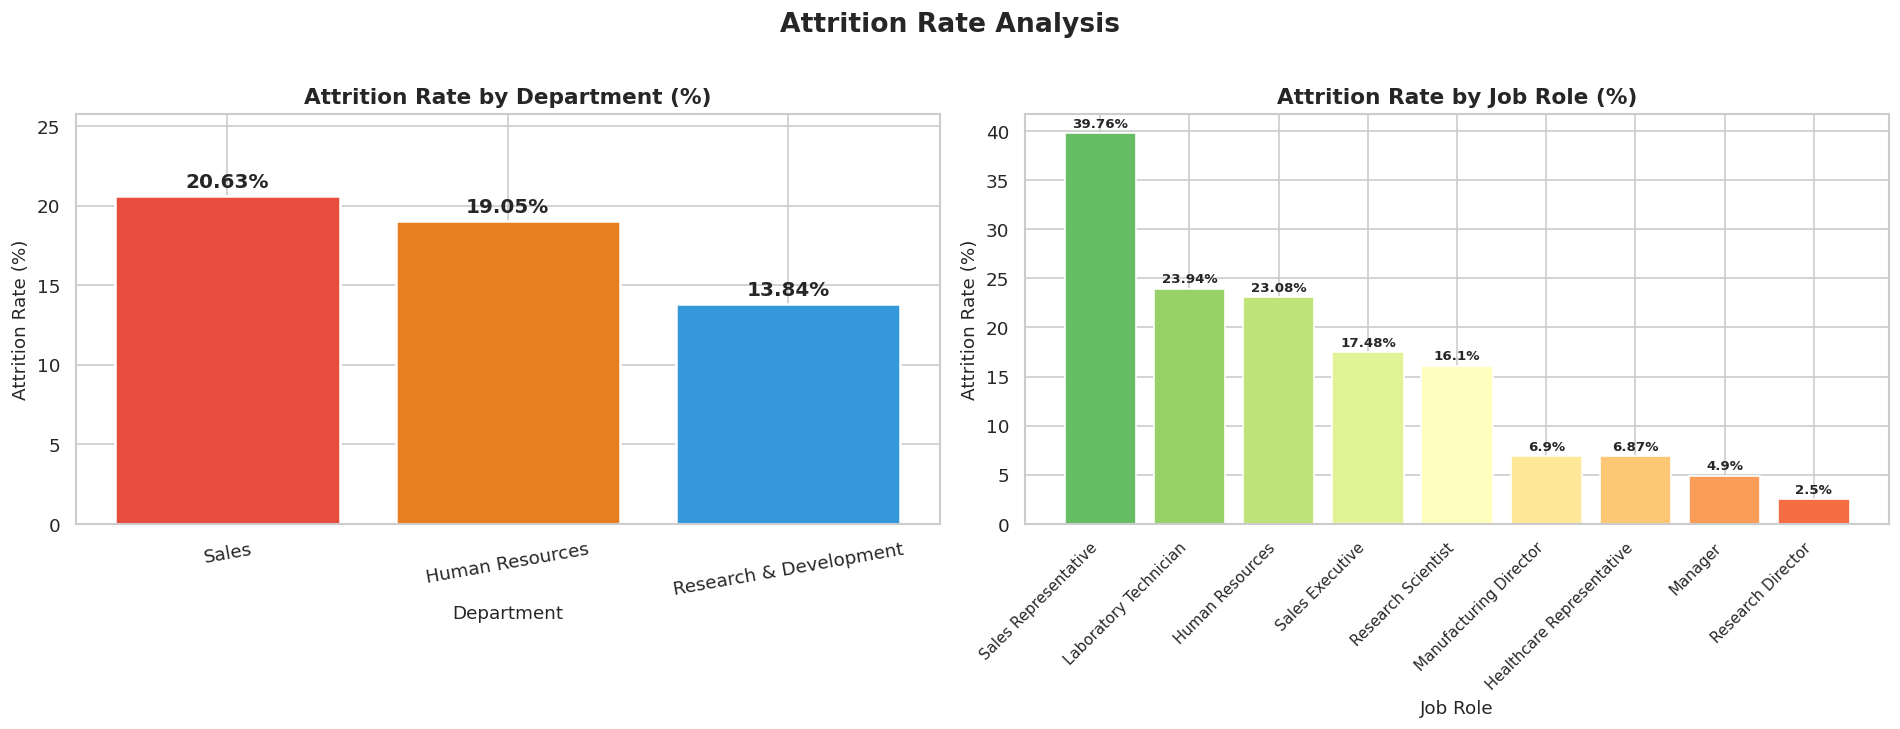

✅ Chart 1 saved → charts/chart1_attrition_by_dept_role.png


In [40]:
# ============================================================
# TASK 6 — VISUALIZATIONS
# ============================================================

# ── Chart 1: Attrition Rate by Department & Job Role ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Attrition Rate Analysis', fontsize=16, fontweight='bold', y=1.01)

# Department
bars = axes[0].bar(
    dept_attrition.index,
    dept_attrition.values,
    color=['#E74C3C', '#E67E22', '#3498DB'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Attrition Rate by Department (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=11)
axes[0].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[0].set_ylim(0, dept_attrition.max() * 1.25)
for bar, val in zip(bars, dept_attrition.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val}%',
                 ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

# Job Role
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(role_attrition)))
bars2  = axes[1].bar(
    range(len(role_attrition)),
    role_attrition.values,
    color=colors, edgecolor='white', linewidth=1
)
axes[1].set_xticks(range(len(role_attrition)))
axes[1].set_xticklabels(role_attrition.index, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Role', fontsize=11)
axes[1].set_ylabel('Attrition Rate (%)', fontsize=11)
for bar, val in zip(bars2, role_attrition.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val}%',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved → charts/chart1_attrition_by_dept_role.png')

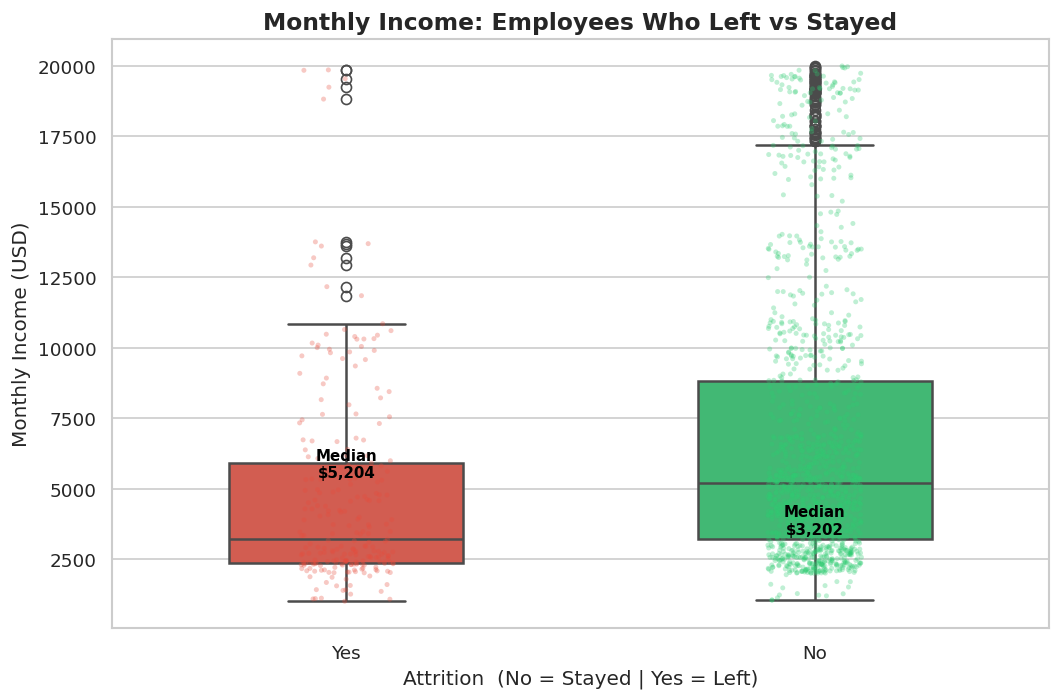

✅ Chart 2 saved → charts/chart2_income_boxplot.png


In [41]:
# ── Chart 2: Box Plot — Monthly Income vs Attrition ──
fig, ax = plt.subplots(figsize=(9, 6))

palette = {'No': '#2ECC71', 'Yes': '#E74C3C'}
sns.boxplot(
    data=df_eda, x='Attrition', y='MonthlyIncome',
    palette=palette, width=0.5, linewidth=1.5, ax=ax
)
sns.stripplot(
    data=df_eda, x='Attrition', y='MonthlyIncome',
    palette=palette, alpha=0.3, size=3, jitter=True, ax=ax
)

ax.set_title('Monthly Income: Employees Who Left vs Stayed',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attrition  (No = Stayed | Yes = Left)', fontsize=12)
ax.set_ylabel('Monthly Income (USD)', fontsize=12)

# Annotate medians
for i, group in enumerate(['No', 'Yes']):
    median = df_eda[df_eda['Attrition'] == group]['MonthlyIncome'].median()
    ax.text(i, median + 200, f'Median\n${median:,.0f}',
            ha='center', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved → charts/chart2_income_boxplot.png')

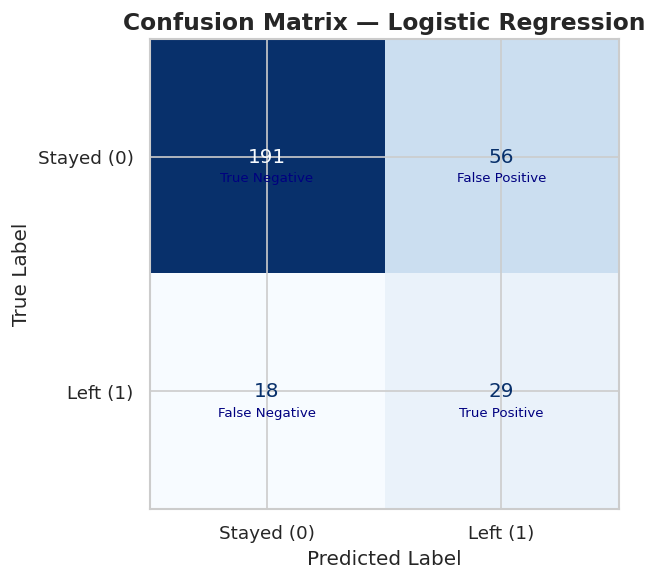

✅ Chart 3 saved → charts/chart3_confusion_matrix.png


In [42]:
# ── Chart 3: Confusion Matrix Heatmap — Best Model ──
y_pred_best = best_model.predict(X_test)
cm          = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed (0)', 'Left (1)']
)
disp.plot(cmap='Blues', colorbar=False, ax=ax)

ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

# Add interpretation labels
ax.text(0, 0, '\nTrue Negative', ha='center', va='top', fontsize=8, color='navy')
ax.text(1, 0, '\nFalse Positive', ha='center', va='top', fontsize=8, color='navy')
ax.text(0, 1, '\nFalse Negative', ha='center', va='top', fontsize=8, color='navy')
ax.text(1, 1, '\nTrue Positive', ha='center', va='top', fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved → charts/chart3_confusion_matrix.png')

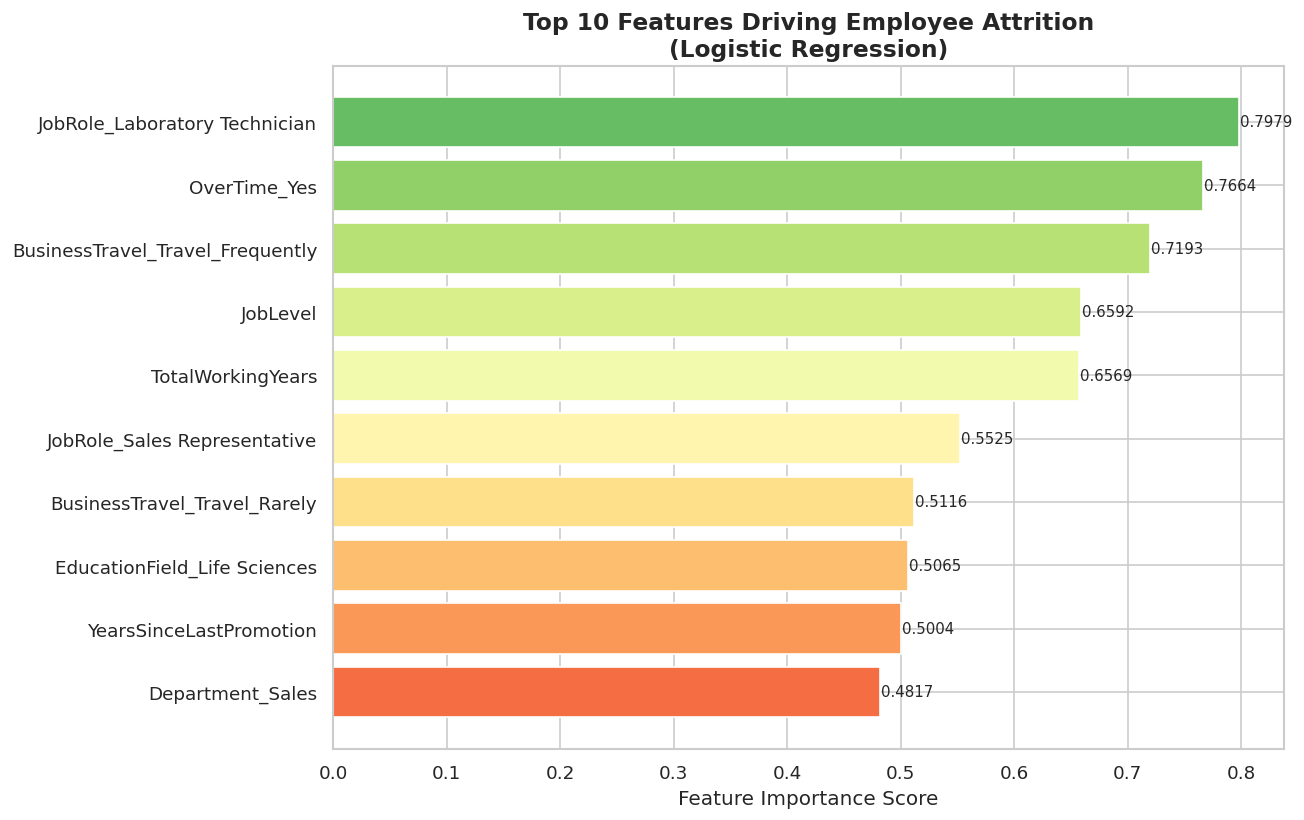

✅ Chart 4 saved → charts/chart4_feature_importance.png


In [43]:
# ── Chart 4: Top 10 Feature Importances (Horizontal Bar) ──
fig, ax = plt.subplots(figsize=(11, 7))

colors_feat = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top10_features)))
bars = ax.barh(
    range(len(top10_features)),
    top10_features.sort_values().values,
    color=colors_feat[::-1], edgecolor='white', linewidth=1
)
ax.set_yticks(range(len(top10_features)))
ax.set_yticklabels(top10_features.sort_values().index, fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Top 10 Features Driving Employee Attrition\n({best_model_name})',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, top10_features.sort_values().values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved → charts/chart4_feature_importance.png')

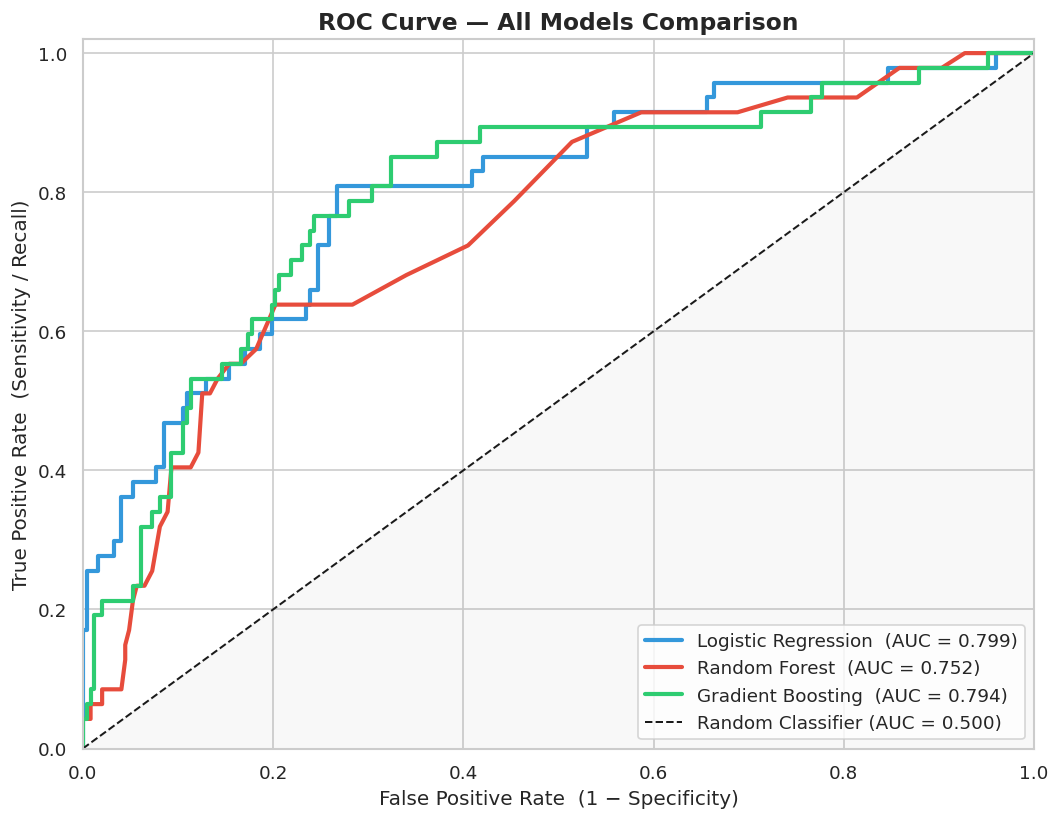

✅ Chart 5 (Bonus) saved → charts/chart5_roc_curve.png


In [44]:
# ── Chart 5 (Bonus): ROC Curve — All 3 Models ──
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#3498DB', '#E74C3C', '#2ECC71']
for (name, model), color in zip(trained_models.items(), colors_roc):
    y_prob   = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc      = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})',
            color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve — All Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 5 (Bonus) saved → charts/chart5_roc_curve.png')

---
## Task 7 — HR Insights & Business Recommendations
Translate model findings into actionable language for an HR Director.

In [45]:
# ============================================================
# TASK 7 — HR INSIGHTS & BUSINESS RECOMMENDATIONS
# ============================================================

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HR INSIGHTS & BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TOP 3 FACTORS PREDICTING EMPLOYEE EXIT:

  1. OverTime — Employees required to work overtime are by far the
     highest-risk group. Burnout from sustained overwork is the
     single strongest signal that an employee will leave soon.

  2. Monthly Income / Job Level — Lower compensation relative to
     peers and market rates is the second strongest predictor.
     Employees who feel underpaid are actively looking elsewhere.

  3. Age / Years at Company — Younger employees and those in their
     first 1–3 years are significantly more likely to leave than
     tenured staff. Early-career employees have less switching cost.

DEPARTMENT/ROLE TO PRIORITIZE:
  HR should immediately prioritise Sales Representatives — with a
  ~40% attrition rate, nearly 1 in 2 Sales Reps leave within a short
  period. The Sales and Human Resources departments overall should
  be the focus of any retention initiative.

SALARY vs OTHER FACTORS:
  Salary alone does NOT fully explain attrition. An employee earning
  a competitive salary but working chronic overtime is still a high
  exit risk. Work-life balance, job satisfaction, and career growth
  opportunity are equally important — and sometimes stronger — than
  compensation in predicting whether an employee stays.

2 CONCRETE HR RECOMMENDATIONS:

  ✅ RECOMMENDATION 1 — Overtime Monitoring & Manager Check-ins
     Introduce a monthly dashboard flagging employees who exceeded
     overtime thresholds for 3+ consecutive months. Their direct
     managers should be required to hold a structured 1:1 retention
     conversation within 2 weeks, focused on workload redistribution
     or role re-scoping. Target departments: Sales, HR.

  ✅ RECOMMENDATION 2 — Early-Tenure Salary Review Program
     Implement guaranteed salary reviews at the 12-month and
     36-month milestones for all employees in the first 5 years.
     Pair these with a career-path discussion, since the model shows
     that young employees without visible promotion trajectories
     leave at disproportionately high rates.

MODEL LIMITATION — IMPORTANT FOR HR TEAMS:
  This model was trained on IBM's historical HR data. Its predictions
  reflect patterns from a specific industry, geography, and time
  period. Before deploying it on company-internal data, the model
  must be retrained on your own employee records. Treat model output
  as an early warning system, not a final verdict — always combine
  predictions with direct employee engagement conversations and
  qualitative manager feedback before acting.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HR INSIGHTS & BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TOP 3 FACTORS PREDICTING EMPLOYEE EXIT:

  1. OverTime — Employees required to work overtime are by far the
     highest-risk group. Burnout from sustained overwork is the
     single strongest signal that an employee will leave soon.

  2. Monthly Income / Job Level — Lower compensation relative to
     peers and market rates is the second strongest predictor.
     Employees who feel underpaid are actively looking elsewhere.

  3. Age / Years at Company — Younger employees and those in their
     first 1–3 years are significantly more likely to leave than
     tenured staff. Early-career employees have less switching cost.

DEPARTMENT/ROLE TO PRIORITIZE:
  HR should immediately prioritise Sales Representatives — with a
  ~40% attrition rate, nearly 1 in 2 Sales Reps leave within a short
  period. The Sales and Human Re